# Indo Thai Quantitative Data Analyst Intern — Take-Home Assessment


**Project flow:** Data validation → timestamp alignment → event clustering → subject taxonomy → price/volume impact → statistical analysis → PEAD → figures → outputs → report.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


## PROJECT SETUP
**What this section does:** Defines folders, input files, horizons, and fixed assumptions used throughout the analysis.

In [41]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ANNOUNCEMENTS_FILE = DATA_DIR / "corporate_announcements.csv"
STOCK_FILES = {
    "RELIANCE": DATA_DIR / "RELIANCE.csv",
    "HDFCBANK": DATA_DIR / "HDFCBANK.csv",
    "NYKAA": DATA_DIR / "NYKAA.csv",
    "HAL": DATA_DIR / "HAL.csv",
    "RVNL": DATA_DIR / "RVNL.csv",
}
HORIZONS_MINUTES = [5, 30, 60]
HORIZONS_DAYS = [1,3, 5, 10, 20]
BASELINE_SESSIONS = 20
CLUSTER_GAP_MINUTES = 30
BOOTSTRAP_REPS = 1000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

SUBJECT_PRIORITY = [
    "Financial Results", "Corporate Actions", "Business / Strategic",
    "Board / Management", "Investor / Analyst", "Credit / Financing",
    "Regulatory / Compliance", "Other"
]


## 1. LOAD ANNOUNCEMENTS
**What this section does:** converts the two important announcement timestamps to datetime. Preferred valid dissemination time; DT_TM is the documented fallback.

In [6]:
announcements = pd.read_csv(ANNOUNCEMENTS_FILE)
announcements["DT_TM"] = pd.to_datetime(announcements["DT_TM"], errors="coerce")
announcements["DissemDT"] = pd.to_datetime(announcements["DissemDT"], errors="coerce")

announcements["event_timestamp"] = announcements["DissemDT"].where(
    announcements["DissemDT"].notna(), announcements["DT_TM"]
)
announcements["timestamp_source"] = np.where(
    announcements["DissemDT"].notna(), "DissemDT", "DT_TM"
)
announcements

,NEWSID,SCRIP_CD,XML_NAME,NEWSSUB,DT_TM,NEWS_DT,CRITICALNEWS,ANNOUNCEMENT_TYPE,QUARTER_ID,FILESTATUS,...,News_submission_dt,DissemDT,TimeDiff,Fld_Attachsize,SUBCATNAME,BSENewsid,Investor_Presentation,AUDIO_VIDEO_FILE,event_timestamp,timestamp_source
0,d4395f8a-6089-4a17-8dec-385a6acb2b67,500180,ANN_500180_D4395F8A-6089-4A17-8DEC-385A6ACB2B67,Announcement under Regulation 30 (LODR)-Credit...,2026-08-19 23:19:39.420,2026-08-19T23:19:39.42,1,A,NaN,N,...,2026-08-19T23:19:39,2026-08-19 23:19:39.420,00:00:00,967155.0,Credit Rating,NaN,NaN,NaN,2026-08-19 23:19:39.420,DissemDT
1,391541fa-8d4b-41b6-9304-1e15bed1d5d8,500180,ANN_500180_391541FA-8D4B-41B6-9304-1E15BED1D5D8,Intimation Under Securities And Exchange Board...,2026-08-19 22:52:54.670,2026-08-19T22:52:54.67,0,A,NaN,N,...,2026-08-19T22:52:54,2026-08-19 22:52:54.670,00:00:00,618910.0,General,NaN,NaN,NaN,2026-08-19 22:52:54.670,DissemDT
2,989d8d2f-2b08-4a1c-8d43-f55bae61c178,500325,ANN_500325_989D8D2F-2B08-4A1C-8D43-F55BAE61C178,Update On Institutional Investors'' Meeting - ...,2026-08-18 20:06:38.747,2026-08-18T20:06:38.747,0,A,NaN,N,...,2026-08-18T20:06:38,2026-08-18 20:06:38.747,00:00:00,238773.0,General,NaN,NaN,NaN,2026-08-18 20:06:38.747,DissemDT
3,b0bc3391-c0aa-44d6-be8d-a10b20b10247,500325,ANN_500325_B0BC3391-C0AA-44D6-BE8D-A10B20B10247,"News Clarification - ""SC Slaps Rs 10 Lakh Fine...",2026-08-18 17:44:19.310,2026-08-18T17:44:19.31,0,A,NaN,N,...,2026-08-18T17:44:19,2026-08-18 17:44:19.310,00:00:00,275828.0,General,NaN,NaN,NaN,2026-08-18 17:44:19.310,DissemDT
4,32de7735-b8e6-4653-b377-0c5762be73af,542649,ANN_542649_32DE7735-B8E6-4653-B377-0C5762BE73AF,Announcement under Regulation 30 (LODR)-Earnin...,2026-08-18 14:24:13.290,2026-08-18T14:24:13.29,0,A,NaN,N,...,2026-08-18T14:24:13,2026-08-18 14:24:13.290,00:00:00,602505.0,Earnings Call Transcript,NaN,NaN,NaN,2026-08-18 14:24:13.290,DissemDT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2525,8dd6068c-176c-4fe7-aa17-cd60df7125b3,500325,ANN_500325_8DD6068C-176C-4FE7-AA17-CD60DF7125B3,Update On Institutional Investors' Meeting,2023-08-22 19:58:13.133,2023-08-22T19:58:13.133,0,A,NaN,N,...,2023-08-22T19:58:13,2023-08-22 19:58:13.133,00:00:00,283022.0,General,NaN,NaN,NaN,2023-08-22 19:58:13.133,DissemDT
2526,0e6a9da6-ac10-4061-af87-1809e8bfd4a5,542649,ANN_542649_0E6A9DA6-AC10-4061-AF87-1809E8BFD4A5,Disclosure Under Regulation 30 Of SEBI (LODR) ...,2023-08-22 17:38:07.087,2023-08-22T17:38:07.087,0,A,NaN,N,...,2023-08-22T17:38:07,2023-08-22 17:38:07.087,00:00:00,777559.0,General,NaN,NaN,NaN,2023-08-22 17:38:07.087,DissemDT
2527,3ec37b08-d06c-4b0e-a288-b3360a9cca47,500180,ANN_500180_3EC37B08-D06C-4B0E-A288-B3360A9CCA47,Compliances-Reg. 39 (3) - Details of Loss of C...,2023-08-22 15:39:01.150,2023-08-22T15:39:01.15,0,A,NaN,N,...,2023-08-22T15:39:01,2023-08-22 15:39:01.150,00:00:00,252187.0,Reg. 39 (3) - Details of Loss of Certificate /...,NaN,NaN,NaN,2023-08-22 15:39:01.150,DissemDT
2528,593fae8a-832d-493d-aa10-9e76debbe034,500180,ANN_500180_593FAE8A-832D-493D-AA10-9E76DEBBE034,Announcement under Regulation 30 (LODR)-Allotment,2023-08-21 21:05:27.310,2023-08-21T21:05:27.31,0,A,NaN,N,...,2023-08-21T21:05:27,2023-08-21 21:05:27.310,00:00:00,162274.0,Allotment of Equity Shares,NaN,NaN,NaN,2023-08-21 21:05:27.310,DissemDT


## 2. ANNOUNCEMENT VALIDATION
**What this section does:** WHAT THIS DOES: Checks missing values, duplicates, timestamp coverage, and records basic announcement-data quality diagnostics.

In [5]:
announcement_missing = announcements.isna().sum()
announcement_diagnostics = pd.DataFrame([{
    "announcement_rows": len(announcements),
    "duplicate_rows": int(announcements.duplicated().sum()),
    "missing_dissem_dt": int(announcements["DissemDT"].isna().sum()),
    "missing_dt_tm": int(announcements["DT_TM"].isna().sum()),
    "missing_event_timestamp": int(announcements["event_timestamp"].isna().sum()),
    "date_min": announcements["event_timestamp"].min(),
    "date_max": announcements["event_timestamp"].max(),
}])
announcement_diagnostics

,announcement_rows,duplicate_rows,missing_dissem_dt,missing_dt_tm,missing_event_timestamp,date_min,date_max
0,2530,0,11,11,11,2023-08-21 18:16:15.450,2026-08-19 23:19:39.420


## 3. ANNOUNCEMENT SUBJECT TAXONOMY
**What this section does:** WHAT THIS DOES: Creates transparent rule-based subject groups from the supplied category, subcategory, headline and subject fields.

In [11]:
text_columns = [
    "SUBCATNAME",
    "CATEGORYNAME",
    "HEADLINE",
    "NEWSSUB"
]


# Combining the four text columns into one column.
# and Missing values are replaced with blank text.
announcements["announcement_text"] = (
    announcements[text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)


# If an announcement does not match any rule,
# it will remain "Other".
announcements["subject"] = "Other"


# Financial Results


mask = announcements["announcement_text"].str.contains(
    "financial result|integrated filing (financial)",
    regex=True,
    na=False
)

announcements.loc[mask, "subject"] = "Financial Results"


# Corporate Actions

mask = (
    announcements["announcement_text"].str.contains(
        "dividend|record date|book closure|bonus|split|buyback|rights issue|allotment",
        regex=True,
        na=False
    )
)

announcements.loc[
    mask & (announcements["subject"] == "Other"),
    "subject"
] = "Corporate Actions"


# Business / Strategic


mask = announcements["announcement_text"].str.contains(
    "order|contract|acquisition|agreement|joint venture|project|mou|subsidiary",
    regex=True,
    na=False
)

announcements.loc[
    mask & (announcements["subject"] == "Other"),
    "subject"
] = "Business / Strategic"



# Board / Management


mask = announcements["announcement_text"].str.contains(
    "board meeting|outcome of board|appointment|resignation|cessation|director|agm|egm",
    regex=True,
    na=False
)

announcements.loc[
    mask & (announcements["subject"] == "Other"),
    "subject"
] = "Board / Management"


# Investor / Analyst


mask = announcements["announcement_text"].str.contains(
    "analyst|investor|earnings call|conference call|investor presentation|presentation|press release",
    regex=True,
    na=False
)

announcements.loc[
    mask & (announcements["subject"] == "Other"),
    "subject"
] = "Investor / Analyst"



# Credit / Financing


mask = announcements["announcement_text"].str.contains(
    "credit rating|rating|debt|borrowing|loan|commercial paper|ncd",
    regex=True,
    na=False
)

announcements.loc[
    mask & (announcements["subject"] == "Other"),
    "subject"
] = "Credit / Financing"



# Regulatory / Compliance

mask = announcements["announcement_text"].str.contains(
    "compliance|secretarial|annual report|brsr|certificate|trading plan|clarification|disclosure|regulation",
    regex=True,
    na=False
)

announcements.loc[
    mask & (announcements["subject"] == "Other"),
    "subject"
] = "Regulatory / Compliance"



# Price-Sensitivity Flag


# These subjects are generally more likely to contain
# potentially price-sensitive information.
announcements["sensitivity"] = "Routine / Lower Signal"

announcements.loc[
    announcements["subject"].isin([
        "Financial Results",
        "Corporate Actions",
        "Business / Strategic",
        "Board / Management",
        "Credit / Financing"
    ]),
    "sensitivity"
] = "Potentially Price-Sensitive"


announcements.loc[
    announcements["subject"] == "Investor / Analyst",
    "sensitivity"
] = "Context-Dependent"



# final distribution


print("Announcement subject counts:")
print(
    announcements["subject"]
    .value_counts()
)


print("\nSensitivity counts:")
print(
    announcements["sensitivity"]
    .value_counts()
)

# Check how many announcements are assigned to each subject.
print("\nSubject distribution:")
print(announcements["subject"].value_counts())

# Show the most common headlines in the largest category for inspection.
print("\nSample Regulatory / Compliance announcements:")
print(
    announcements[
        announcements["subject"] == "Regulatory / Compliance"
    ][["HEADLINE", "CATEGORYNAME", "SUBCATNAME"]].head(10)
)

Announcement subject counts:
subject
Regulatory / Compliance    844
Investor / Analyst         403
Board / Management         301
Other                      281
Business / Strategic       247
Financial Results          237
Corporate Actions          180
Credit / Financing          37
Name: count, dtype: int64

Sensitivity counts:
sensitivity
Routine / Lower Signal         1125
Potentially Price-Sensitive    1002
Context-Dependent               403
Name: count, dtype: int64

Subject distribution:
subject
Regulatory / Compliance    844
Investor / Analyst         403
Board / Management         301
Other                      281
Business / Strategic       247
Financial Results          237
Corporate Actions          180
Credit / Financing          37
Name: count, dtype: int64

Sample Regulatory / Compliance announcements:
                                             HEADLINE    CATEGORYNAME  \
1   Intimation under Securities and Exchange Board...  Company Update   
3   Please refer our let

C:\Users\samar\AppData\Local\Temp\ipykernel_29248\1105388297.py:28: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = announcements["announcement_text"].str.contains(


## 4. EVENT CLUSTERING
**What this section does:** stock so multiple communications about one event are not double-counted. Save announcement/event audit tables.

In [20]:
working = announcements.dropna(
    subset=["event_timestamp"]
).copy()

working = working.sort_values(
    ["SCRIP_CD", "event_timestamp"]
).reset_index(drop=True)


# Calculate the time gap from the previous announcement
working["gap_minutes"] = (
    working.groupby("SCRIP_CD")["event_timestamp"]
    .diff()
    .dt.total_seconds()
    / 60
)


# A new event starts when:
# 1. It is the first announcement for that stock, OR
# 2. The gap from the previous announcement is > 30 minutes
working["new_event"] = (
    working["gap_minutes"].isna()
    | (working["gap_minutes"] > 30)
)


# Give every independent event a number
working["event_number"] = (
    working.groupby("SCRIP_CD")["new_event"]
    .cumsum()
)


# Create a unique event ID
working["event_cluster"] = (
    working["SCRIP_CD"].astype(str)
    + "_"
    + working["event_number"].astype(str)
)


# Subject priority when multiple announcements
# belong to the same event
subject_order = {
    "Financial Results": 1,
    "Corporate Actions": 2,
    "Business / Strategic": 3,
    "Board / Management": 4,
    "Investor / Analyst": 5,
    "Credit / Financing": 6,
    "Regulatory / Compliance": 7,
    "Other": 8
}


cluster_rows = []


for cluster_id, group in working.groupby("event_cluster"):

    group = group.sort_values("event_timestamp")

    group["priority"] = (
        group["subject"]
        .map(subject_order)
        .fillna(99)
    )

    main_subject = (
        group.sort_values("priority")
        .iloc[0]["subject"]
    )

    cluster_rows.append({

        "event_cluster": cluster_id,

        "SCRIP_CD": group.iloc[0]["SCRIP_CD"],

        "stock": group.iloc[0]["SLONGNAME"],

        "announcement_timestamp": (
            group["event_timestamp"].min()
        ),

        # Keep the source of the timestamp
        "timestamp_source": ";".join(
            group["timestamp_source"]
            .dropna()
            .unique()
        ),

        # Keep the sensitivity classification
        "sensitivity": (
            "Potentially Price-Sensitive"
            if main_subject in [
                "Financial Results",
                "Corporate Actions",
                "Business / Strategic",
                "Board / Management",
                "Credit / Financing"
            ]
            else (
                "Context-Dependent"
                if main_subject == "Investor / Analyst"
                else "Routine / Lower Signal"
            )
        ),

        "subject": main_subject,

        "member_count": len(group),

        "member_newsid": ", ".join(
            group["NEWSID"]
            .astype(str)
        ),

        "member_subcategories": "; ".join(
            group["SUBCATNAME"]
            .fillna("Other")
            .astype(str)
            .unique()
        ),

        "cluster_headlines": " || ".join(
            group["HEADLINE"]
            .fillna("")
            .astype(str)
        ),

        "earnings_event": (
            "Financial Results"
            in group["subject"].values
        )
    })


# Create final independent-event table
events = pd.DataFrame(cluster_rows)

events["event_date"] = (
    events["announcement_timestamp"]
    .dt.normalize()
)


# Save outputs
announcements.to_csv(
    OUTPUT_DIR / "announcement_audit.csv",
    index=False
)

events.to_csv(
    OUTPUT_DIR / "event_clusters.csv",
    index=False
)


print("Total announcements:", len(announcements))
print("Independent event clusters:", len(events))

Total announcements: 2530
Independent event clusters: 2096


## 5. LOAD AND VALIDATE ALL FIVE STOCK DATASETS
**What this section does:** WHAT THIS DOES: Reads every one-minute OHLCV file, checks basic data quality, identifies sessions, and builds historical volume baselines.

In [18]:
stock_cache = {}
validation_rows = []

for symbol, path in STOCK_FILES.items():

    df = pd.read_csv(path)

    required_columns = [
        "date", "open", "high", "low",
        "close", "volume", "oi"
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{symbol}: missing columns {missing_columns}"
        )

    # Convert date and numeric columns
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    for col in ["open", "high", "low", "close", "volume", "oi"]:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


    # Data quality checking
   

    duplicate_rows = df.duplicated().sum()
    duplicate_timestamps = df["date"].duplicated().sum()
    invalid_timestamps = df["date"].isna().sum()

    # Checking whether OHLC values are logically valid
    invalid_ohlc = (
        (df["open"] <= 0)
        | (df["high"] <= 0)
        | (df["low"] <= 0)
        | (df["close"] <= 0)
        | (df["high"] < df["low"])
        | (df["high"] < df["open"])
        | (df["high"] < df["close"])
        | (df["low"] > df["open"])
        | (df["low"] > df["close"])
    )

    df["invalid_ohlc"] = invalid_ohlc


    # Creating trading-session information
 

    df = df.sort_values("date").reset_index(drop=True)

    df["session_date"] = df["date"].dt.normalize()

    session_sizes = (
        df.groupby("session_date")
        .size()
    )

    df["session_length"] = (
        df["session_date"].map(session_sizes)
    )

    df["minute_index"] = (
        df.groupby("session_date")
        .cumcount()
    )

  
    # Calculating historical volume baseline

    baseline_group = [
        "session_length",
        "minute_index"
    ]

    df["previous_volume"] = (
        df.groupby(baseline_group)["volume"]
        .shift(1)
    )

    df["volume_baseline"] = (
        df.groupby(baseline_group)["previous_volume"]
        .transform(
            lambda x: x.rolling(
                BASELINE_SESSIONS,
                min_periods=10
            ).median()
        )
    )


    # Saving validation results
  

    mode_length = (
        int(session_sizes.mode().iloc[0])
        if len(session_sizes) > 0
        else 0
    )

    validation_rows.append({
        "symbol": symbol,
        "rows": len(df),
        "duplicate_rows": int(duplicate_rows),
        "duplicate_timestamps": int(duplicate_timestamps),
        "invalid_timestamps": int(invalid_timestamps),
        "missing_values_total": int(
            df.isna().sum().sum()
        ),
        "invalid_ohlc_rows": int(
            invalid_ohlc.sum()
        ),
        "zero_volume_rows": int(
            (df["volume"] == 0).sum()
        ),
        "sessions": int(
            df["session_date"].nunique()
        ),
        "earliest_timestamp": df["date"].min(),
        "latest_timestamp": df["date"].max(),
        "nonstandard_sessions": int(
            (session_sizes != mode_length).sum()
        ) if mode_length else 0,
        "modal_session_length": mode_length
    })


    stock_cache[symbol] = df


# Creating one summary table for all five stocks
validation_summary = pd.DataFrame(
    validation_rows
)

# Saving the validation results
validation_summary.to_csv(
    OUTPUT_DIR / "validation_summary.csv",
    index=False
)

print("Stock validation completed.")
print(validation_summary)


# CHECKING WHERE MISSING VALUES OCCUR


for symbol, df in stock_cache.items():

    print("\n" + "=" * 50)
    print(symbol)
    print("=" * 50)

    print(
        df.isna().sum()[
            df.isna().sum() > 0
        ]
    )


# CHECKING INVALID OHLC ROWS


for symbol, df in stock_cache.items():

    bad_rows = df[df["invalid_ohlc"]]

    if len(bad_rows) > 0:

        print("\n", symbol)
        print(
            bad_rows[
                ["date", "open", "high", "low", "close", "volume"]
            ]
        )

Stock validation completed.
     symbol    rows  duplicate_rows  duplicate_timestamps  invalid_timestamps  \
0  RELIANCE  277510               0                     0                   0   
1  HDFCBANK  277510               0                     0                   0   
2     NYKAA  277508               0                     0                   0   
3       HAL  277510               0                     0                   0   
4      RVNL  277509               0                     0                   0   

   missing_values_total  invalid_ohlc_rows  zero_volume_rows  sessions  \
0                  5420                  0               190       744   
1                  5420                  1               187       744   
2                  6166                  0               191       744   
3                  5420                  1               187       744   
4                  5418                  0               191       744   

   earliest_timestamp    latest_timestam

## 6. EVENT ALIGNMENT + EVENT-LEVEL METRICS
**What this section does:** tradable one-minute bar, then calculates 5/30/60-minute, D0, and D+1/D+5/D+10/D+20 price and volume metrics.

In [43]:
code_map = {
    500325: "RELIANCE",
    500180: "HDFCBANK",
    543384: "NYKAA",
    541154: "HAL",
    542649: "RVNL"
}

results = []


for scrip_code, event_group in events.groupby("SCRIP_CD"):

    symbol = code_map.get(int(scrip_code))

    if symbol is None:
        continue

    stock = stock_cache[symbol].copy()

    # Creating trading-session information
    sessions = (
        stock.groupby("session_date")
        .agg(
            session_open=("date", "min"),
            session_close=("date", "max")
        )
        .sort_index()
    )

    session_dates = pd.DatetimeIndex(sessions.index)

    # Mapping each timestamp to its row number
    timestamp_to_position = {
        timestamp: position
        for position, timestamp in enumerate(stock["date"])
    }

    # Finding first and last row of each trading session
    session_positions = {}

    for session_date, group in stock.groupby("session_date"):
        session_positions[session_date] = (
            group.index.min(),
            group.index.max()
        )


    # Processing every independent event
    

    for _, event in event_group.iterrows():

        announcement_time = event["announcement_timestamp"]

        result = {
            "event_cluster": event["event_cluster"],
            "stock": event["stock"],
            "SCRIP_CD": event["SCRIP_CD"],
            "announcement_timestamp": announcement_time,
            "timestamp_source": event["timestamp_source"],
            "subject": event["subject"],
            "sensitivity": event["sensitivity"],
            "earnings_event": bool(event["earnings_event"]),
            "member_count": int(event["member_count"]),
            "member_newsid": event["member_newsid"],
            "member_subcategories": event["member_subcategories"],
            "cluster_headlines": event["cluster_headlines"]
        }


        # 1. Finding the correct trading session
     
        if pd.isna(announcement_time):
            result["alignment_status"] = "invalid_event_timestamp"
            result["exclusion_reason"] = "invalid_event_timestamp"
            results.append(result)
            continue

        announcement_date = announcement_time.normalize()

        position = session_dates.searchsorted(
            announcement_date
        )

        same_day = (
            position < len(session_dates)
            and session_dates[position] == announcement_date
        )

        overnight = False


        # Announcement happened on a trading day
        if same_day:

            session_date = session_dates[position]

            session_open = sessions.loc[
                session_date, "session_open"
            ]

            session_close = sessions.loc[
                session_date, "session_close"
            ]


            # Before market was open
            if announcement_time < session_open:

                target_position = position
                candidate_time = session_open
                overnight = True
                alignment_reason = "pre_open_same_day"


            # During market session
            elif announcement_time <= session_close:

                candidate_time = announcement_time.ceil("min")


                # The complete bar exists on the same session
                if candidate_time <= session_close:

                    target_position = position
                    alignment_reason = "in_session"


                # Announcement was too close to/after session end
                else:

                    target_position = position + 1
                    candidate_time = None
                    overnight = True
                    alignment_reason = "after_session_close"


            # After market close
            else:

                target_position = position + 1
                candidate_time = None
                overnight = True
                alignment_reason = "after_session_close"


        # Announcement happened on a non-trading day
        else:

            target_position = position
            candidate_time = None
            overnight = True
            alignment_reason = "non_trading_day"


        # No future trading session available
        if target_position >= len(session_dates):

            result["alignment_status"] = "no_future_session"
            result["alignment_reason"] = alignment_reason
            result["announcement_date"] = announcement_date
            result["exclusion_reason"] = "no_future_session"

            results.append(result)
            continue


        # 2. Find the effective event bar
   

        target_session = session_dates[target_position]

        target_open = sessions.loc[
            target_session, "session_open"
        ]

        target_close = sessions.loc[
            target_session, "session_close"
        ]


        # For pre-open, after-close and weekend events,
        # the first tradable bar is the next session's open.
        if candidate_time is None:
            candidate_time = target_open

        elif (
            target_session != announcement_date
            or candidate_time < target_open
        ):
            candidate_time = target_open


        result["announcement_date"] = announcement_date
        result["effective_event_time"] = candidate_time
        result["effective_session_date"] = target_session
        result["same_day_session"] = same_day
        result["overnight_included"] = overnight
        result["alignment_reason"] = alignment_reason


        # The exact expected bar must exist.
        if candidate_time not in timestamp_to_position:

            result["alignment_status"] = "missing_effective_bar"
            result["exclusion_reason"] = "missing_effective_bar"

            results.append(result)
            continue


        event_position = timestamp_to_position[candidate_time]

        event_bar = stock.iloc[event_position]

        result["alignment_status"] = "aligned"
        result["event_row_position"] = event_position
        result["session_open"] = target_open
        result["session_close"] = target_close


     
        # 3. Choosing the starting price
       

        # Overnight event:
        # use previous regular-session close
        if overnight:

            target_index = session_dates.searchsorted(
                target_session
            )

            if target_index <= 0:

                result["exclusion_reason"] = (
                    "missing_previous_session_close"
                )

                results.append(result)
                continue


            previous_session = session_dates[
                target_index - 1
            ]

            previous_close_position = (
                session_positions[previous_session][1]
            )

            start_price = float(
                stock.iloc[previous_close_position]["close"]
            )

            start_time = stock.iloc[
                previous_close_position
            ]["date"]


        # In-session event:
        # use effective event bar open
        else:

            start_price = float(event_bar["open"])
            start_time = event_bar["date"]


        result["start_price"] = start_price
        result["start_price_time"] = start_time
        result["event_bar_open"] = float(event_bar["open"])
        result["event_bar_close"] = float(event_bar["close"])
        result["event_bar_volume"] = float(event_bar["volume"])


        
        # 4. Calculate 5, 30 and 60 minute impact
        
        usable = True


        for horizon in HORIZONS_MINUTES:

            end_position = event_position + horizon
            name = f"{horizon}m"


            # Not enough rows
            if end_position > len(stock):

                result[f"window_reason_{name}"] = (
                    "insufficient_rows"
                )

                usable = False
                continue


            window = stock.iloc[
                event_position:end_position
            ].copy()


            # Wrong number of bars
            if len(window) != horizon:

                result[f"window_reason_{name}"] = (
                    "insufficient_rows"
                )

                usable = False
                continue


            # Window must stay inside the same trading session
            if (
                window["session_date"].nunique() != 1
                or window["session_date"].iloc[0] != target_session
            ):

                result[f"window_reason_{name}"] = (
                    "cross_session_window"
                )

                usable = False
                continue


            # Check for missing minute(s)
            minute_difference = (
                window["date"]
                .diff()
                .dropna()
                .dt.total_seconds()
                / 60
            )


            if not minute_difference.eq(1).all():

                result[f"window_reason_{name}"] = (
                    "internal_minute_gap"
                )

                usable = False
                continue


            # Do not use an invalid OHLC bar
            if window["invalid_ohlc"].any():

                result[f"window_reason_{name}"] = (
                    "invalid_ohlc_in_window"
                )

                usable = False
                continue


            # Price return
            end_close = float(
                window.iloc[-1]["close"]
            )

            result[f"return_{name}_pct"] = (
                (end_close - start_price)
                / start_price
                * 100
            )


            # Volume impact
            actual_volume = float(
                window["volume"].sum()
            )

            baseline_volume = np.nan

            if window["volume_baseline"].notna().all():

                baseline_volume = float(
                    window["volume_baseline"].sum()
                )


            if (
                pd.notna(baseline_volume)
                and baseline_volume != 0
            ):

                volume_ratio = (
                    actual_volume
                    / baseline_volume
                )

                volume_change = (
                    volume_ratio - 1
                ) * 100

            else:

                volume_ratio = np.nan
                volume_change = np.nan


            result[f"volume_ratio_{name}"] = volume_ratio
            result[f"volume_change_{name}_pct"] = volume_change


            # Price range
            result[f"range_{name}_pct"] = (
                (
                    window["high"].max()
                    - window["low"].min()
                )
                / start_price
                * 100
            )


            result[f"window_reason_{name}"] = "usable"


      
        # 5. Event-to-session-close return
       

        close_position = session_positions[
            target_session
        ][1]


        if close_position < event_position:

            result["exclusion_reason"] = "invalid_d0_order"

            results.append(result)
            continue


        d0_data = stock.iloc[
            event_position:close_position + 1
        ].copy()


        # Check that all bars are from one session
        if d0_data["session_date"].nunique() != 1:

            result["exclusion_reason"] = "invalid_d0_session"

            results.append(result)
            continue


        # Check for missing minutes
        d0_difference = (
            d0_data["date"]
            .diff()
            .dropna()
            .dt.total_seconds()
            / 60
        )


        if not d0_difference.eq(1).all():

            result["exclusion_reason"] = (
                "incomplete_event_to_close_window"
            )

            results.append(result)
            continue


        # Check OHLC quality
        if d0_data["invalid_ohlc"].any():

            result["exclusion_reason"] = (
                "invalid_ohlc_in_d0_window"
            )

            results.append(result)
            continue


        d0_close = float(
            stock.iloc[close_position]["close"]
        )

        result["d0_close"] = d0_close

        result["d0_close_time"] = stock.iloc[
            close_position
        ]["date"]

        result["d0_return_pct"] = (
            (d0_close - start_price)
            / start_price
            * 100
        )

        result["d0_range_pct"] = (
            (
                d0_data["high"].max()
                - d0_data["low"].min()
            )
            / start_price
            * 100
        )


      
        # 6. D+1, D+5, D+10 and D+20 returns


        event_session_index = (
            session_dates.searchsorted(target_session)
        )


        for days in HORIZONS_DAYS:

            future_index = (
                event_session_index + days
            )


            if future_index >= len(session_dates):

                result[f"dplus{days}_return_pct"] = np.nan
                result[f"dplus{days}_close"] = np.nan

                continue


            future_session = session_dates[
                future_index
            ]

            future_close_position = (
                session_positions[future_session][1]
            )

            future_close = float(
                stock.iloc[future_close_position]["close"]
            )


            result[f"dplus{days}_return_pct"] = (
                (future_close - d0_close)
                / d0_close
                * 100
            )

            result[f"dplus{days}_close"] = future_close

            result[f"dplus{days}_close_time"] = stock.iloc[
                future_close_position
            ]["date"]


        # Direction of the initial D0 reaction
        if pd.notna(result["d0_return_pct"]):

            result["initial_direction"] = int(
                np.sign(result["d0_return_pct"])
            )

        else:

            result["initial_direction"] = 0


        if usable:
            result["exclusion_reason"] = "usable"
        else:
            result["exclusion_reason"] = (
                "incomplete_short_window"
            )


        results.append(result)


# Creating the final event-level results table
event_results = pd.DataFrame(results)

event_results = event_results.sort_values(
    "announcement_timestamp"
).reset_index(drop=True)

print("Event-level analysis completed.")
print("Total events:", len(event_results))

Event-level analysis completed.
Total events: 2096


In [53]:
# FINAL MARKET EVENTS

aligned_events = event_results[
    event_results["alignment_status"] == "aligned"
].copy()

final_events = []

subject_priority = {
    "Financial Results": 1,
    "Corporate Actions": 2,
    "Business / Strategic": 3,
    "Board / Management": 4,
    "Investor / Analyst": 5,
    "Credit / Financing": 6,
    "Regulatory / Compliance": 7,
    "Other": 8
}

for (stock, event_time), group in aligned_events.groupby(
    ["stock", "effective_event_time"]
):

    group = group.sort_values("announcement_timestamp")

    # Give priority to Financial Results if it exists
    group["priority"] = (
        group["subject"]
        .map(subject_priority)
        .fillna(99)
    )

    main_subject = (
        group.sort_values("priority")
        .iloc[0]["subject"]
    )

    first = group.iloc[0]

    final_events.append({
        "event_cluster": first["event_cluster"],
        "stock": stock,
        "SCRIP_CD": first["SCRIP_CD"],

        "announcement_timestamp": (
            group["announcement_timestamp"].min()
        ),

        "effective_event_time": event_time,
        "effective_session_date": first[
            "effective_session_date"
        ],

        "subject": main_subject,
        "sensitivity": first["sensitivity"],

        "merged_cluster_count": len(group),

        "member_newsid": "; ".join(
            group["member_newsid"].astype(str)
        ),

        "cluster_headlines": " || ".join(
            group["cluster_headlines"].astype(str)
        ),

        # Keep earnings event if ANY merged cluster is financial results
        "earnings_event": group[
            "earnings_event"
        ].any(),

        # Market metrics are identical for the same effective bar
        "start_price": first["start_price"],
        "start_price_time": first["start_price_time"],

        "event_bar_open": first["event_bar_open"],
        "event_bar_close": first["event_bar_close"],
        "event_bar_volume": first["event_bar_volume"],

        "return_5m_pct": first["return_5m_pct"],
        "return_30m_pct": first["return_30m_pct"],
        "return_60m_pct": first["return_60m_pct"],

        "volume_ratio_5m": first["volume_ratio_5m"],
        "volume_ratio_30m": first["volume_ratio_30m"],
        "volume_ratio_60m": first["volume_ratio_60m"],

        "volume_change_5m_pct": first["volume_change_5m_pct"]
        if "volume_change_5m_pct" in first else np.nan,

        "volume_change_30m_pct": first[
            "volume_change_30m_pct"
        ],

        "volume_change_60m_pct": first[
            "volume_change_60m_pct"
        ]
        if "volume_change_60m_pct" in first else np.nan,

        "range_5m_pct": first["range_5m_pct"]
        if "range_5m_pct" in first else np.nan,

        "range_30m_pct": first[
            "range_30m_pct"
        ],

        "range_60m_pct": first["range_60m_pct"]
        if "range_60m_pct" in first else np.nan,

        "d0_close": first["d0_close"],
        "d0_close_time": first["d0_close_time"],
        "d0_return_pct": first["d0_return_pct"],
        "d0_range_pct": first["d0_range_pct"],

        "dplus1_return_pct": first["dplus1_return_pct"],
        "dplus3_return_pct": first["dplus3_return_pct"],
        "dplus5_return_pct": first["dplus5_return_pct"],
        "dplus10_return_pct": first["dplus10_return_pct"],
        "dplus20_return_pct": first["dplus20_return_pct"],
        
        "initial_direction": first["initial_direction"],
        "exclusion_reason": first["exclusion_reason"]
    })


final_events = pd.DataFrame(final_events)

final_events = final_events.sort_values(
    "effective_event_time"
).reset_index(drop=True)

print("Original event clusters:", len(event_results))
print("Final market events:", len(final_events))
print(
    "Market-bar duplicates consolidated:",
    len(event_results[event_results["alignment_status"] == "aligned"])
    - len(final_events)
)

final_events.to_csv(
    OUTPUT_DIR / "final_market_events.csv",
    index=False
)

Original event clusters: 2096
Final market events: 1673
Market-bar duplicates consolidated: 422


## 7. STRONG-IMPACT FLAG
**What this section does:** WHAT THIS DOES: Defines a strong 30-minute impact as the top 5% of absolute 30-minute returns in the analysis sample.

In [45]:
threshold = (
    final_events["return_30m_pct"]
    .dropna()
    .abs()
    .quantile(0.95)
)

final_events["strong_impact_30m"] = (
    final_events["return_30m_pct"]
    .abs() >= threshold
)

final_events["strong_impact_threshold_pct"] = threshold


# Save the final event-level results
final_events.to_csv(
    OUTPUT_DIR / "event_level_results.csv",
    index=False
)


print("Strong-impact threshold:", threshold)

print(
    "Strong-impact events:",
    final_events["strong_impact_30m"].sum()
)

Strong-impact threshold: 2.9063254423316547
Strong-impact events: 82


## 8. SUBJECT-LEVEL STATISTICS
**What this section does:** WHAT THIS DOES: Calculates mean, median, sample size, bootstrap 95% CI and a one-sample t-test for each subject/metric combination.

In [46]:
usable_events = final_events[
    final_events["exclusion_reason"] == "usable"
].copy()


metrics = [
    "return_5m_pct",
    "return_30m_pct",
    "return_60m_pct",
    "d0_return_pct",
    "volume_change_30m_pct",
    "range_30m_pct"
]


summary_rows = []


for metric in metrics:

    for subject, group in usable_events.groupby("subject"):

        values = (
            group[metric]
            .dropna()
            .astype(float)
            .to_numpy()
        )

        n = len(values)


        # Mean and median
        mean_value = (
            np.mean(values)
            if n > 0
            else np.nan
        )

        median_value = (
            np.median(values)
            if n > 0
            else np.nan
        )


        # Standard deviation
        std_value = (
            np.std(values, ddof=1)
            if n > 1
            else np.nan
        )


        # Bootstrap 95% confidence interval
        if n >= 2:

            random = np.random.default_rng(
                RANDOM_SEED
            )

            samples = random.choice(
                values,
                size=(BOOTSTRAP_REPS, n),
                replace=True
            )

            sample_means = samples.mean(axis=1)

            ci_low, ci_high = np.percentile(
                sample_means,
                [2.5, 97.5]
            )

        else:

            ci_low = np.nan
            ci_high = np.nan


        # One-sample t-test:
        # H0 = mean return/impact is zero
        if n >= 2 and std_value > 0:

            t_test_pvalue = (
                stats.ttest_1samp(
                    values,
                    0
                ).pvalue
            )

        else:

            t_test_pvalue = np.nan


        summary_rows.append({

            "subject": subject,

            "metric": metric,

            "n": n,

            "mean": mean_value,

            "median": median_value,

            "std": std_value,

            "ci95_low": ci_low,

            "ci95_high": ci_high,

            "t_test_pvalue_vs_zero": t_test_pvalue

        })


# Create final subject-level table
subject_summary = pd.DataFrame(
    summary_rows
)


# Number of independent events in each subject
subject_counts = (
    usable_events
    .groupby("subject")
    .size()
    .reset_index(
        name="independent_events"
    )
)


# Add event counts to the summary
subject_summary = subject_summary.merge(
    subject_counts,
    on="subject",
    how="left"
)


# Groups with fewer than 10 events are descriptive only
subject_summary["interpretation_flag"] = np.where(
    subject_summary["independent_events"] < 10,
    "Descriptive only (<10 independent events)",
    "Eligible for statistical inference"
)


# Save results
subject_summary.to_csv(
    OUTPUT_DIR / "subject_summary.csv",
    index=False
)


print("Subject-level statistics completed.")

print(
    subject_summary.head(20)
)

Subject-level statistics completed.
                    subject          metric    n      mean    median  \
0        Board / Management   return_5m_pct  180 -0.103094  0.023276   
1      Business / Strategic   return_5m_pct  199  0.490132  0.317784   
2         Corporate Actions   return_5m_pct  141  0.098023  0.024704   
3        Credit / Financing   return_5m_pct   27 -0.037453  0.053619   
4         Financial Results   return_5m_pct  142  0.119912  0.069904   
5        Investor / Analyst   return_5m_pct  261  0.114756  0.052138   
6                     Other   return_5m_pct  167  0.528344  0.139324   
7   Regulatory / Compliance   return_5m_pct  453  0.107493  0.040636   
8        Board / Management  return_30m_pct  180 -0.098318  0.015540   
9      Business / Strategic  return_30m_pct  199  0.512372  0.283122   
10        Corporate Actions  return_30m_pct  141  0.079109 -0.001443   
11       Credit / Financing  return_30m_pct   27  0.046334  0.031867   
12        Financial Results 

## 9. KRUSKAL-WALLIS SUBJECT COMPARISON
**What this section does:** WHAT THIS DOES: Tests whether 30-minute return distributions differ across subject groups without assigning arbitrary numeric labels.

In [47]:
groups = []
group_names = []

for subject, group in usable_events.groupby("subject"):

    returns = (
        group["return_30m_pct"]
        .dropna()
        .to_numpy()
    )

    # Use only subjects with at least 10 events
    if len(returns) >= 10:
        groups.append(returns)
        group_names.append(subject)


# Run the Kruskal-Wallis test
if len(groups) >= 2:

    statistic, p_value = stats.kruskal(*groups)

else:

    statistic = np.nan
    p_value = np.nan


# Store the result
subject_test = pd.DataFrame({
    "metric": ["return_30m_pct"],
    "test": ["Kruskal-Wallis"],
    "groups_tested": [len(groups)],
    "statistic": [statistic],
    "p_value": [p_value],
    "groups": ["; ".join(group_names)]
})


# Save the result
subject_test.to_csv(
    OUTPUT_DIR / "subject_statistical_test.csv",
    index=False
)


print("Kruskal-Wallis test completed.")
print(subject_test)

Kruskal-Wallis test completed.
           metric            test  groups_tested  statistic   p_value  \
0  return_30m_pct  Kruskal-Wallis              8  23.730247  0.001271   

                                              groups  
0  Board / Management; Business / Strategic; Corp...  


## 10. STOCK-WISE SUBJECT COMPARISON
**What this section does:** WHAT THIS DOES: Produces the stock-by-subject breakdown required for comparing announcement effects across the five companies.

In [48]:
# Using only final independent market events
usable_events = final_events[
    final_events["exclusion_reason"] == "usable"
].copy()


# Storing results here
stock_subject_rows = []


# Group data by stock and announcement subject
for (stock, subject), group in usable_events.groupby(
    ["stock", "subject"]
):

    # Get usable 30-minute returns
    returns = (
        group["return_30m_pct"]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    n = len(returns)


    # Basic return statistics

    if n > 0:

        mean_return = np.mean(returns)
        median_return = np.median(returns)

    else:

        mean_return = np.nan
        median_return = np.nan


    # Standard deviation
   

    if n > 1:

        std_return = np.std(
            returns,
            ddof=1
        )

    else:

        std_return = np.nan



    # Bootstrap 95% confidence interval


    if n >= 2:

        random = np.random.default_rng(
            RANDOM_SEED
        )

        bootstrap_samples = random.choice(
            returns,
            size=(BOOTSTRAP_REPS, n),
            replace=True
        )

        bootstrap_means = (
            bootstrap_samples.mean(axis=1)
        )

        ci_low, ci_high = np.percentile(
            bootstrap_means,
            [2.5, 97.5]
        )

    else:

        ci_low = np.nan
        ci_high = np.nan


   
    # Average 30-minute volume change
   

    volume_values = (
        group["volume_change_30m_pct"]
        .dropna()
    )

    if len(volume_values) > 0:

        mean_volume_change = (
            volume_values.mean()
        )

    else:

        mean_volume_change = np.nan



    # Save the result


    stock_subject_rows.append({

        "stock": stock,

        "subject": subject,

        "n": n,

        "mean_30m_return_pct": mean_return,

        "median_30m_return_pct": median_return,

        "std_30m_return_pct": std_return,

        "ci95_low": ci_low,

        "ci95_high": ci_high,

        "mean_30m_volume_change_pct":
            mean_volume_change

    })


# Create the final stock-subject table
stock_subject_summary = pd.DataFrame(
    stock_subject_rows
)


# Sort for easier reading
stock_subject_summary = (
    stock_subject_summary
    .sort_values(
        ["stock", "subject"]
    )
    .reset_index(drop=True)
)


# Save the result
stock_subject_summary.to_csv(
    OUTPUT_DIR / "stock_subject_summary.csv",
    index=False
)


# Display the first 20 rows
print("Stock-wise subject comparison completed.")

print(
    stock_subject_summary
    .head(20)
    .to_string(index=False)
)

Stock-wise subject comparison completed.
                      stock                 subject   n  mean_30m_return_pct  median_30m_return_pct  std_30m_return_pct  ci95_low  ci95_high  mean_30m_volume_change_pct
FSN E-Commerce Ventures Ltd      Board / Management  22            -0.018234              -0.070073            1.201698 -0.483591   0.478293                   78.030281
FSN E-Commerce Ventures Ltd    Business / Strategic  15            -0.058904               0.015242            0.812541 -0.457131   0.371234                   67.375848
FSN E-Commerce Ventures Ltd       Corporate Actions  33            -0.095968              -0.025880            1.302307 -0.542708   0.331734                  128.016122
FSN E-Commerce Ventures Ltd      Credit / Financing   4            -0.755148              -0.847371            1.853745 -2.312072   0.893999                  137.588481
FSN E-Commerce Ventures Ltd       Financial Results  30             0.324943              -0.036793            1.5

In [49]:
extreme_events = (
    event_results[
        event_results["return_30m_pct"].notna()
    ]
    .copy()
)

extreme_events["abs_return"] = (
    extreme_events["return_30m_pct"].abs()
)

extreme_events = extreme_events.sort_values(
    "abs_return",
    ascending=False
)

print(
    extreme_events[
        [
            "stock",
            "subject",
            "announcement_timestamp",
            "effective_event_time",
            "overnight_included",
            "start_price",
            "event_bar_open",
            "event_bar_close",
            "return_30m_pct"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

               stock                 subject  announcement_timestamp effective_event_time overnight_included  start_price  event_bar_open  event_bar_close  return_30m_pct
Rail Vikas Nigam Ltd      Board / Management 2023-09-03 12:03:47.423  2023-09-04 09:15:00               True       138.50           143.0           146.50        8.808664
Rail Vikas Nigam Ltd      Board / Management 2023-09-02 17:13:43.373  2023-09-04 09:15:00               True       138.50           143.0           146.50        8.808664
Rail Vikas Nigam Ltd Regulatory / Compliance 2023-09-02 18:07:28.057  2023-09-04 09:15:00               True       138.50           143.0           146.50        8.808664
Rail Vikas Nigam Ltd    Business / Strategic 2023-09-02 22:48:26.693  2023-09-04 09:15:00               True       138.50           143.0           146.50        8.808664
Rail Vikas Nigam Ltd    Business / Strategic 2024-07-09 19:15:04.693  2024-07-10 09:15:00               True       545.00           560.0        

## 11. PEAD ANALYSIS
**What this section does:** WHAT THIS DOES: Uses financial-results events and measures cumulative post-D0 movement at D+1, D+3, D+5, D+10 and D+20, plus continuation rates.

In [54]:
# Keep only usable Financial Results events
pead_events = final_events[
    (final_events["earnings_event"] == True)
    & (final_events["exclusion_reason"] == "usable")
    & (final_events["d0_return_pct"].notna())
].copy()


pead_rows = []

# Analyse every required PEAD horizon

for horizon in HORIZONS_DAYS:
    return_column = f"dplus{horizon}_return_pct"



    # POOLED ANALYSIS — ALL STOCKS


    groups = [
        ("pooled", "ALL", pead_events)
    ]


    # Add each stock separately
    for stock, stock_group in pead_events.groupby("stock"):

        groups.append(
            ("stock", stock, stock_group)
        )


 
    # Calculate statistics for each scope
   
    for scope, stock_name, group in groups:

        returns = (
            group[return_column]
            .dropna()
            .astype(float)
        )

        n = len(returns)


        # Mean and median drift
        if n > 0:

            mean_drift = returns.mean()
            median_drift = returns.median()

        else:

            mean_drift = np.nan
            median_drift = np.nan


 
        # Bootstrap 95% confidence interval


        if n >= 2:

            random = np.random.default_rng(
                RANDOM_SEED
            )

            samples = random.choice(
                returns.to_numpy(),
                size=(BOOTSTRAP_REPS, n),
                replace=True
            )

            sample_means = samples.mean(axis=1)

            ci_low, ci_high = np.percentile(
                sample_means,
                [2.5, 97.5]
            )

        else:

            ci_low = np.nan
            ci_high = np.nan


   
        # Continuation analysis


        initial_direction = np.sign(
            group.loc[
                returns.index,
                "d0_return_pct"
            ]
        )

        later_direction = np.sign(returns)

        valid = initial_direction != 0

        continuation_n = int(
            valid.sum()
        )


        if continuation_n > 0:

            continuation_count = (
                initial_direction[valid].to_numpy()
                == later_direction[valid].to_numpy()
            ).sum()

            continuation = (
                continuation_count
                / continuation_n
            )


            # 95% Wilson confidence interval
            z = 1.96

            denominator = (
                1
                + (z ** 2 / continuation_n)
            )

            centre = (
                continuation
                + (z ** 2 / (2 * continuation_n))
            ) / denominator

            margin = (
                z
                * np.sqrt(
                    (
                        continuation
                        * (1 - continuation)
                        / continuation_n
                    )
                    + (
                        z ** 2
                        / (4 * continuation_n ** 2)
                    )
                )
                / denominator
            )

            continuation_low = (
                centre - margin
            )

            continuation_high = (
                centre + margin
            )

        else:

            continuation = np.nan
            continuation_low = np.nan
            continuation_high = np.nan


      
        # Save results
  

        pead_rows.append({

            "scope": scope,

            "stock": stock_name,

            "horizon_sessions": horizon,

            "n": n,

            "mean_drift_pct": mean_drift,

            "median_drift_pct": median_drift,

            "ci95_low": ci_low,

            "ci95_high": ci_high,

            "continuation_pct": (
                continuation * 100
                if pd.notna(continuation)
                else np.nan
            ),

            "continuation_ci95_low_pct": (
                continuation_low * 100
                if pd.notna(continuation_low)
                else np.nan
            ),

            "continuation_ci95_high_pct": (
                continuation_high * 100
                if pd.notna(continuation_high)
                else np.nan
            )
        })


# Create final PEAD summary
pead_summary = pd.DataFrame(
    pead_rows
)


# Save the results
pead_summary.to_csv(
    OUTPUT_DIR / "pead_summary.csv",
    index=False
)


print("PEAD analysis completed.")
print(pead_summary)

PEAD analysis completed.
     scope                        stock  horizon_sessions    n  \
0   pooled                          ALL                 1  142   
1    stock  FSN E-Commerce Ventures Ltd                 1   30   
2    stock                HDFC Bank Ltd                 1   40   
3    stock    Hindustan Aeronautics Ltd                 1   20   
4    stock         Rail Vikas Nigam Ltd                 1   28   
5    stock      Reliance Industries Ltd                 1   24   
6   pooled                          ALL                 3  142   
7    stock  FSN E-Commerce Ventures Ltd                 3   30   
8    stock                HDFC Bank Ltd                 3   40   
9    stock    Hindustan Aeronautics Ltd                 3   20   
10   stock         Rail Vikas Nigam Ltd                 3   28   
11   stock      Reliance Industries Ltd                 3   24   
12  pooled                          ALL                 5  142   
13   stock  FSN E-Commerce Ventures Ltd            

## 12. CREATE FIGURES
**What this section does:** WHAT THIS DOES: Exports six clear PNG charts required/recommended by the assessment.

All 6 figures created successfully.


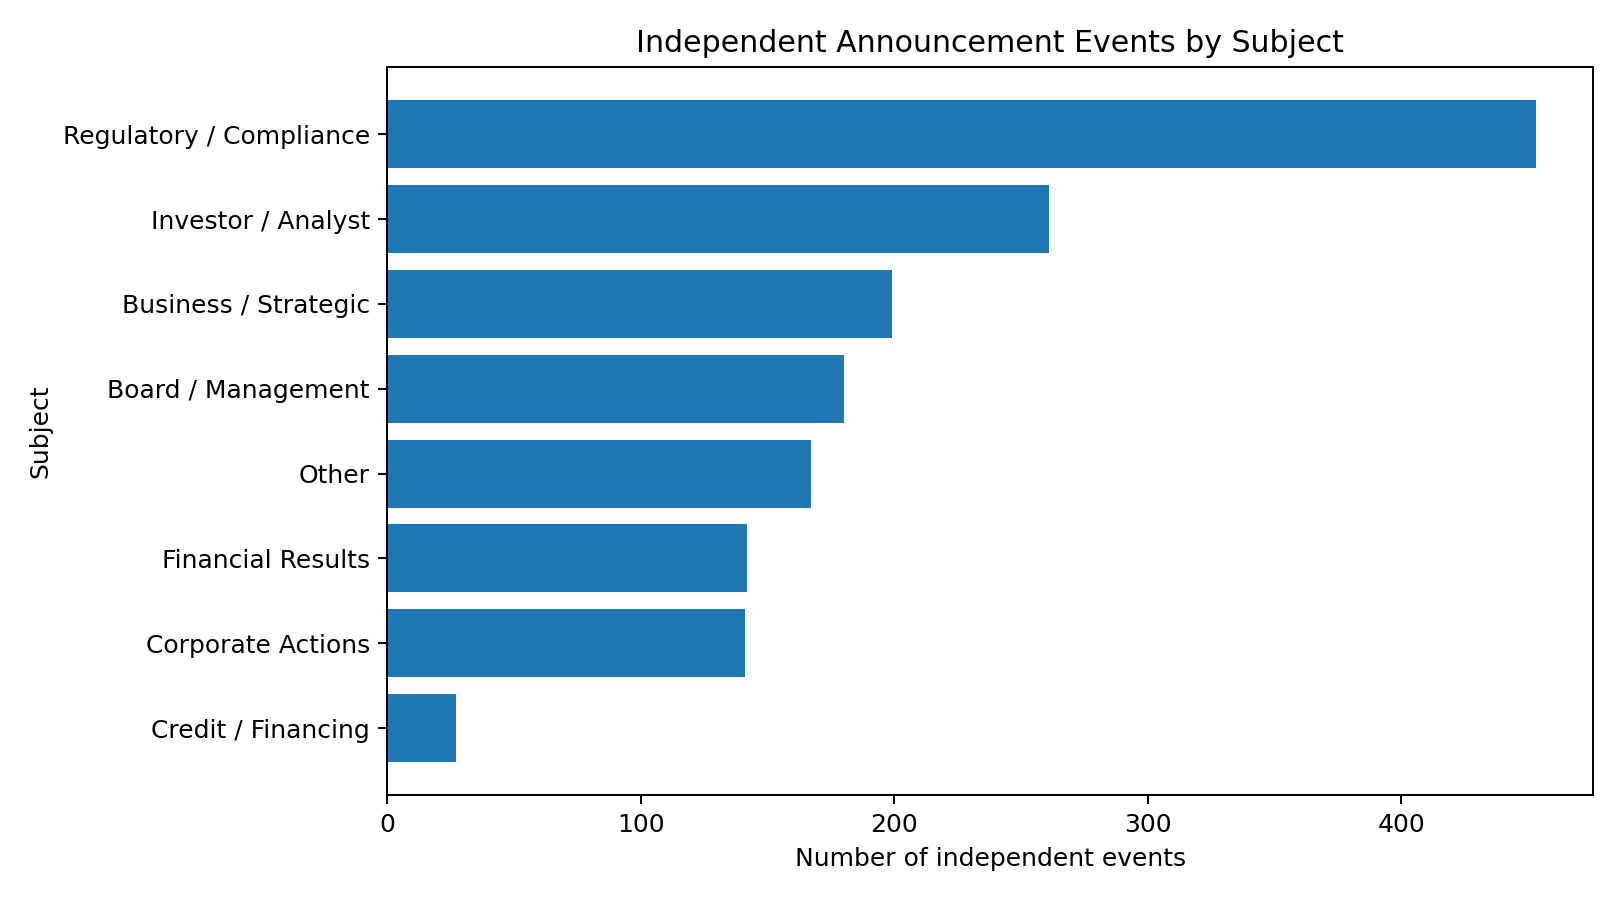

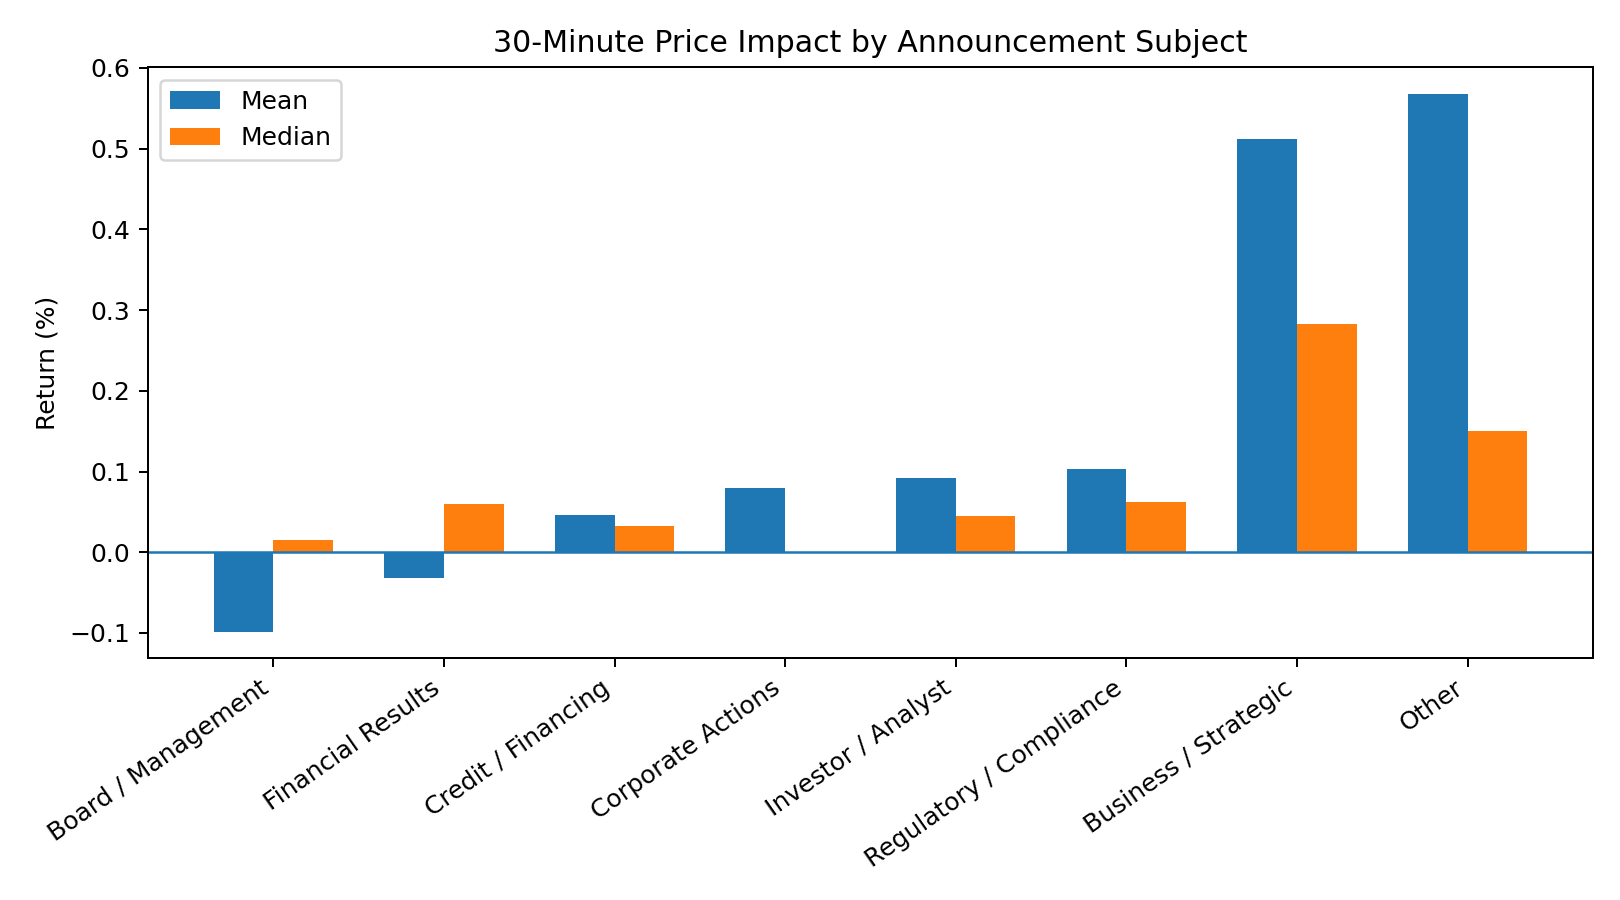

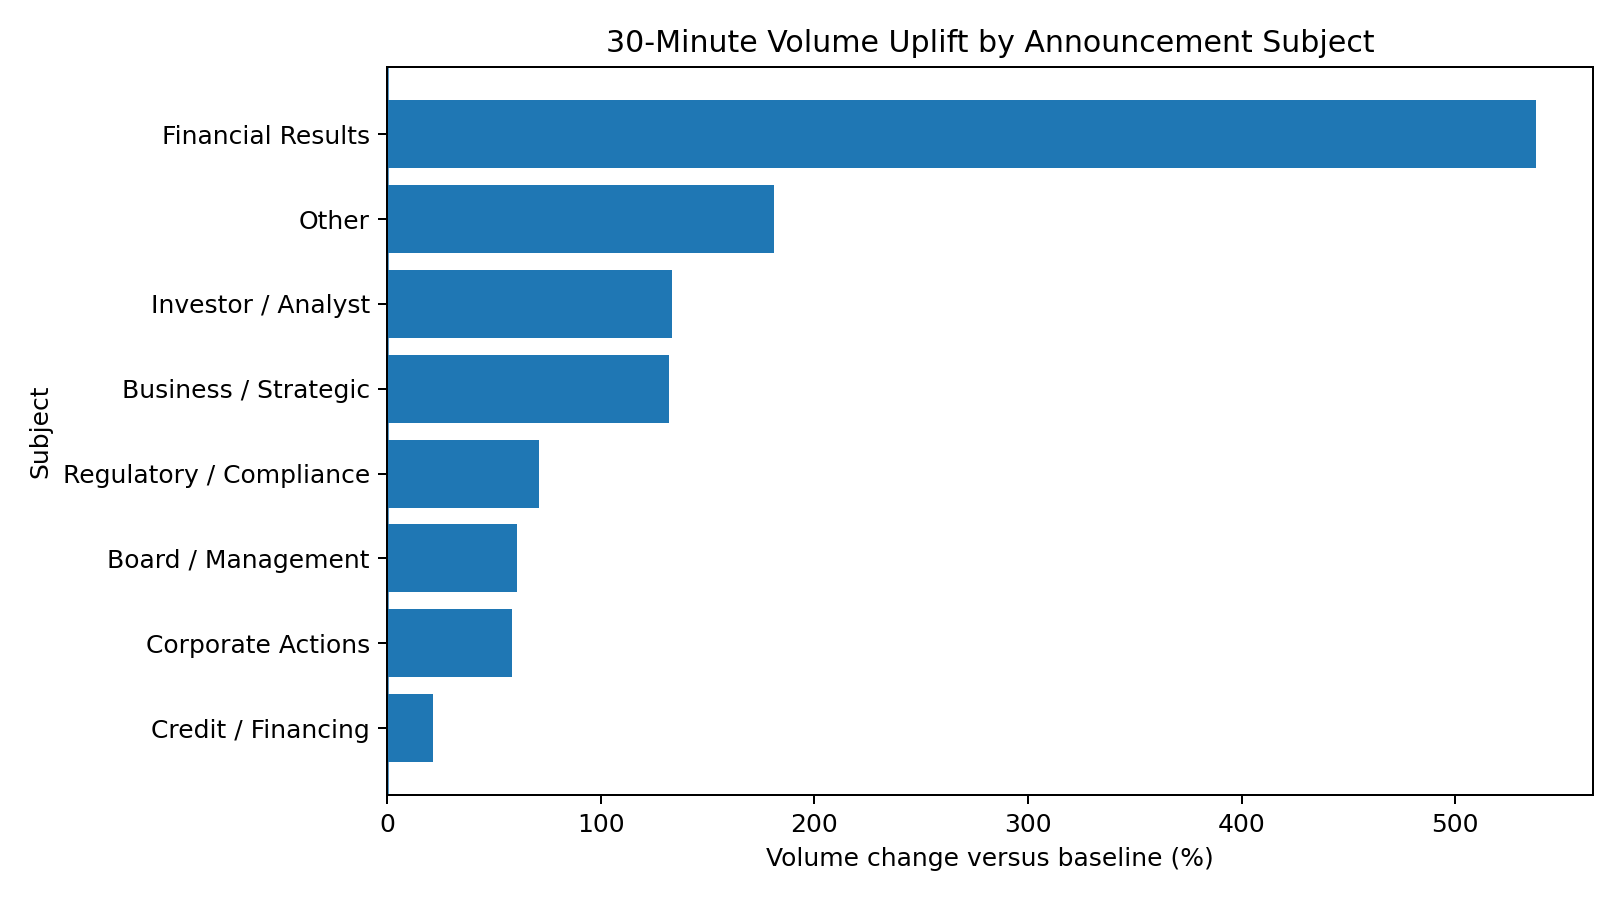

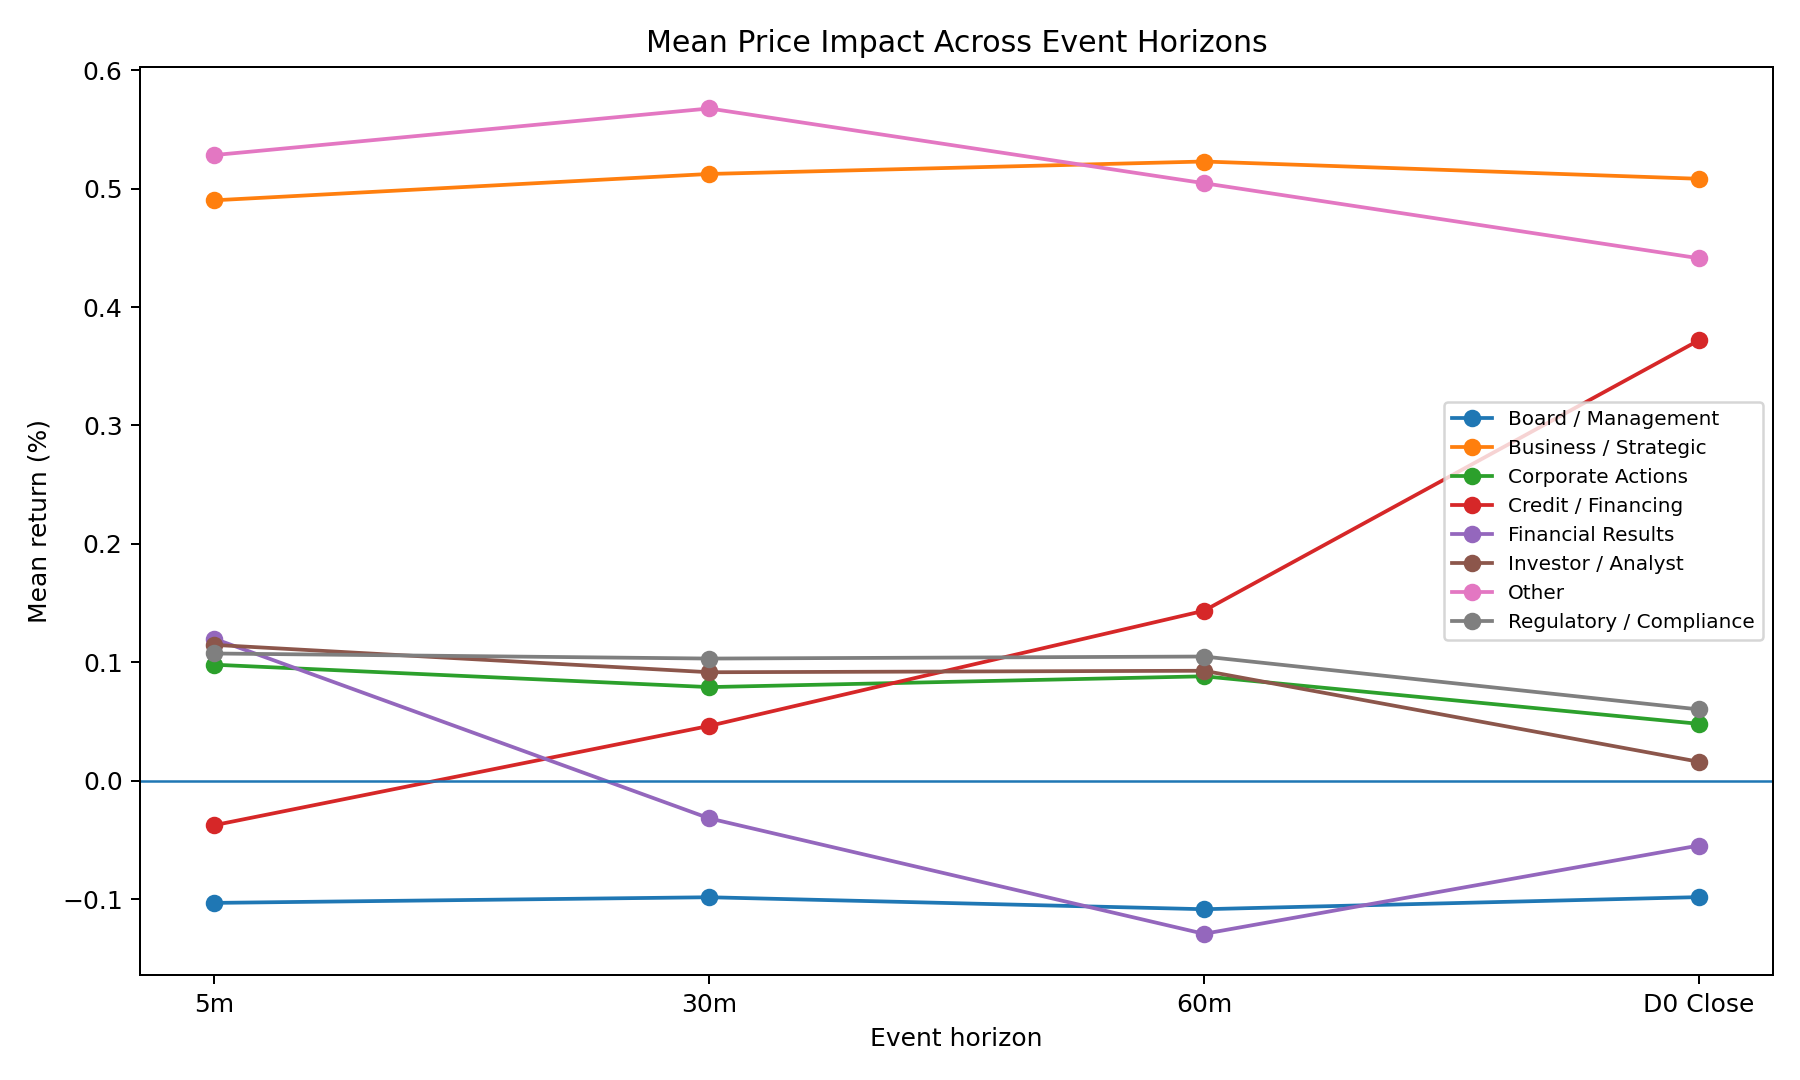

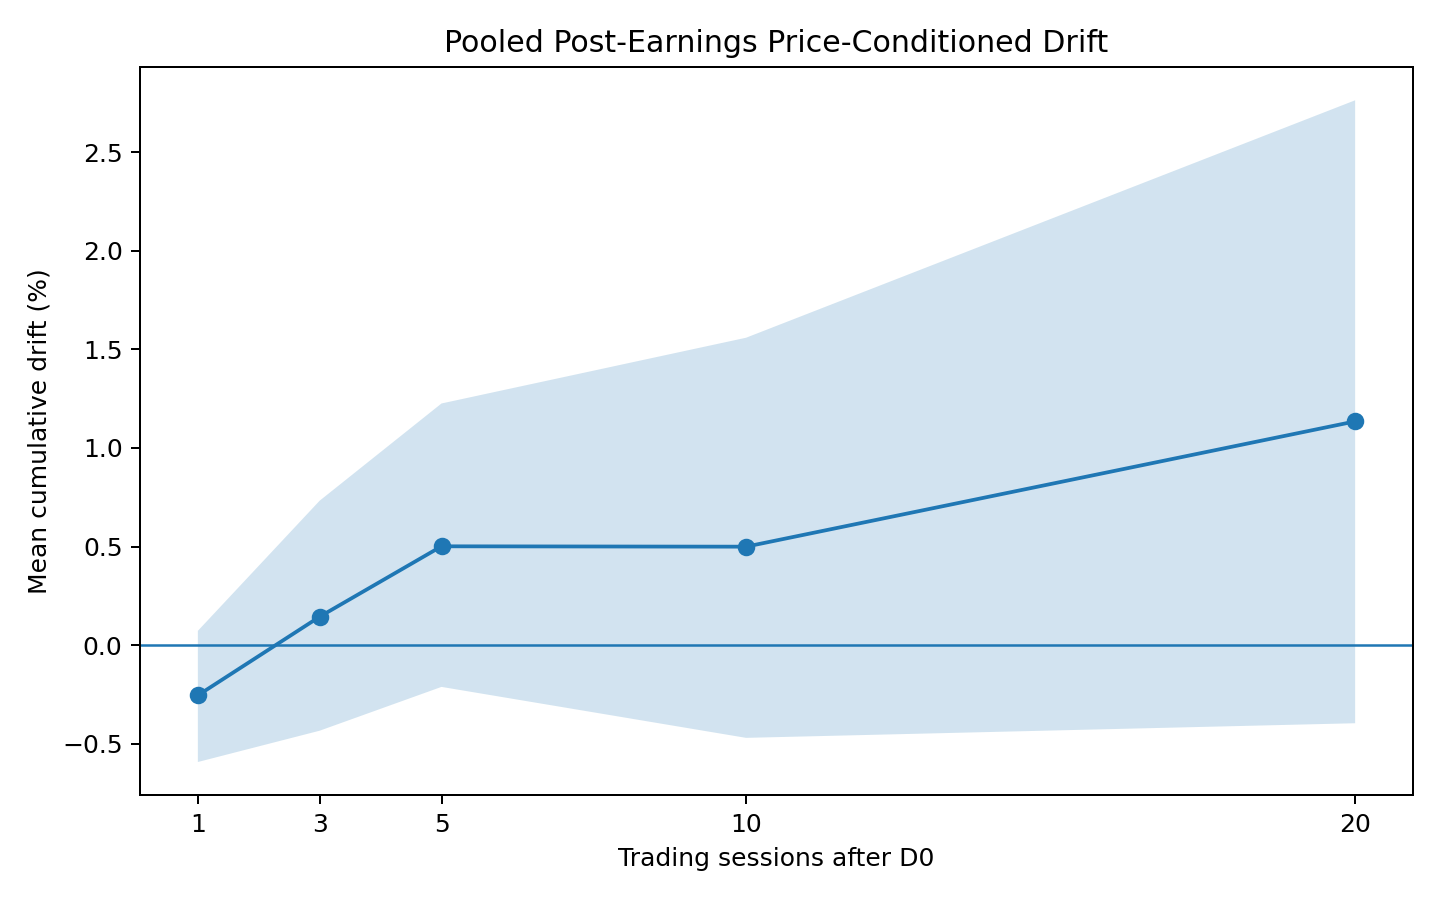

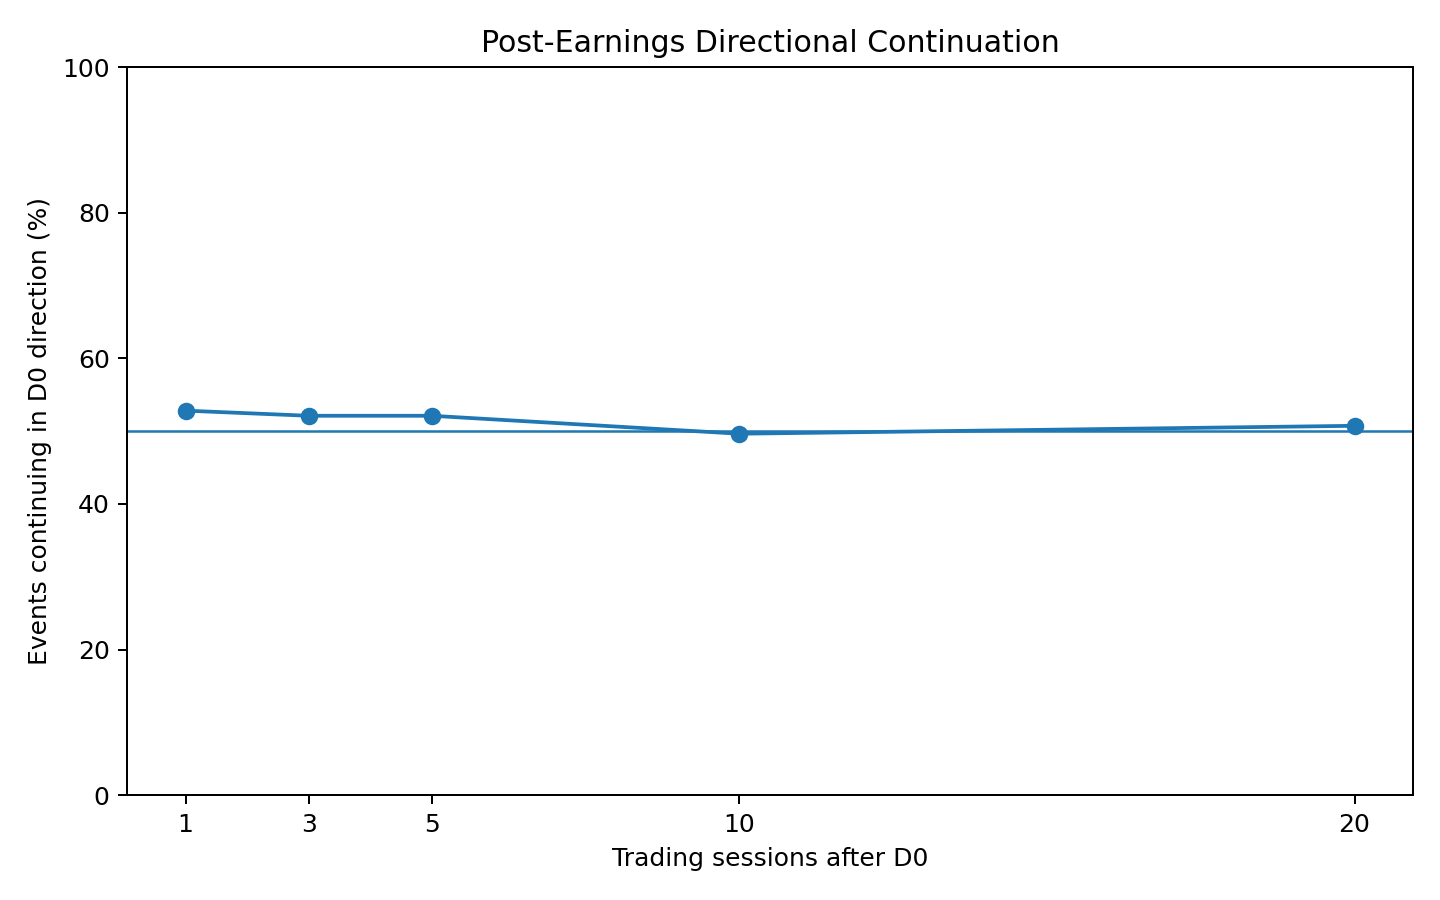

In [56]:
# Number of independent events by subject

counts = (
    usable_events["subject"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    counts.index,
    counts.values
)

ax.set_title(
    "Independent Announcement Events by Subject"
)

ax.set_xlabel(
    "Number of independent events"
)

ax.set_ylabel(
    "Subject"
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "01_event_counts_by_subject.png",
    dpi=180
)

plt.close(fig)



# 30-minute return by subject

subject_return = (
    subject_summary[
        subject_summary["metric"] == "return_30m_pct"
    ]
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(
    len(subject_return)
)

width = 0.35

ax.bar(
    x - width / 2,
    subject_return["mean"],
    width,
    label="Mean"
)

ax.bar(
    x + width / 2,
    subject_return["median"],
    width,
    label="Median"
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xticks(x)

ax.set_xticklabels(
    subject_return["subject"],
    rotation=35,
    ha="right"
)

ax.set_ylabel(
    "Return (%)"
)

ax.set_title(
    "30-Minute Price Impact by Announcement Subject"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "02_subject_30m_return.png",
    dpi=180
)

plt.close(fig)



# 30-minute volume change by subject


subject_volume = (
    subject_summary[
        subject_summary["metric"] == "volume_change_30m_pct"
    ]
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    subject_volume["subject"],
    subject_volume["mean"]
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Volume change versus baseline (%)"
)

ax.set_ylabel(
    "Subject"
)

ax.set_title(
    "30-Minute Volume Uplift by Announcement Subject"
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "03_subject_30m_volume.png",
    dpi=180
)

plt.close(fig)


# Price impact across event horizons


horizon_data = (
    usable_events
    .groupby("subject")[
        [
            "return_5m_pct",
            "return_30m_pct",
            "return_60m_pct",
            "d0_return_pct"
        ]
    ]
    .mean()
)

horizon_data = horizon_data.rename(
    columns={
        "return_5m_pct": "5m",
        "return_30m_pct": "30m",
        "return_60m_pct": "60m",
        "d0_return_pct": "D0 Close"
    }
)

fig, ax = plt.subplots(figsize=(10, 6))

for subject in horizon_data.index:

    ax.plot(
        horizon_data.columns,
        horizon_data.loc[subject].values,
        marker="o",
        label=subject
    )

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Event horizon"
)

ax.set_ylabel(
    "Mean return (%)"
)

ax.set_title(
    "Mean Price Impact Across Event Horizons"
)

ax.legend(
    fontsize=8
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "04_subject_return_horizons.png",
    dpi=180
)

plt.close(fig)


# Pooled PEAD drift


pooled_pead = (
    pead_summary[
        pead_summary["scope"] == "pooled"
    ]
    .sort_values("horizon_sessions")
)

fig, ax = plt.subplots(figsize=(8, 5))

x = pooled_pead[
    "horizon_sessions"
].to_numpy()

y = pooled_pead[
    "mean_drift_pct"
].to_numpy()

lower = pooled_pead[
    "ci95_low"
].to_numpy()

upper = pooled_pead[
    "ci95_high"
].to_numpy()

ax.plot(
    x,
    y,
    marker="o"
)

ax.fill_between(
    x,
    lower,
    upper,
    alpha=0.2
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xticks(
    HORIZONS_DAYS
)

ax.set_xlabel(
    "Trading sessions after D0"
)

ax.set_ylabel(
    "Mean cumulative drift (%)"
)

ax.set_title(
    "Pooled Post-Earnings Price-Conditioned Drift"
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "05_pead_pooled_drift.png",
    dpi=180
)

plt.close(fig)


# PEAD continuation


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    pooled_pead["horizon_sessions"],
    pooled_pead["continuation_pct"],
    marker="o"
)

ax.axhline(
    50,
    linewidth=1
)

ax.set_xticks(
    HORIZONS_DAYS
)

ax.set_ylim(
    0,
    100
)

ax.set_xlabel(
    "Trading sessions after D0"
)

ax.set_ylabel(
    "Events continuing in D0 direction (%)"
)

ax.set_title(
    "Post-Earnings Directional Continuation"
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "06_pead_continuation.png",
    dpi=180
)

plt.close(fig)


print("All 6 figures created successfully.")


# generated figures inside
from IPython.display import display, Image

display(Image(filename=str(FIGURE_DIR / "01_event_counts_by_subject.png")))
display(Image(filename=str(FIGURE_DIR / "02_subject_30m_return.png")))
display(Image(filename=str(FIGURE_DIR / "03_subject_30m_volume.png")))
display(Image(filename=str(FIGURE_DIR / "04_subject_return_horizons.png")))
display(Image(filename=str(FIGURE_DIR / "05_pead_pooled_drift.png")))
display(Image(filename=str(FIGURE_DIR / "06_pead_continuation.png")))

## 13. GENERATE REPORT
**What this section does:** WHAT THIS DOES: Writes a markdown report containing methodology, computed results, statistical tests, PEAD summary, limitations and figures.

In [57]:
report = []

report.append(
    "# Indo Thai Quantitative Data Analyst Intern – "
    "Take-Home Assessment\n"
)

# 1. Objective


report.append("## 1. Objective\n")

report.append(
    "This analysis studies how BSE corporate announcements "
    "are associated with short-term stock-price and trading-volume "
    "movements and with post-earnings price drift for five supplied stocks.\n"
)



# 2. Data and validation


report.append("## 2. Data and Validation\n")

report.append(
    f"The analysis started with **{len(announcements):,} announcements**. "
    f"After the same-stock 30-minute clustering rule, there were "
    f"**{len(event_results):,} event clusters**. After consolidating "
    f"multiple clusters that mapped to the same stock and effective "
    f"market bar, the final sample contained **{len(final_events):,} "
    f"independent market events**.\n"
)

report.append("### Validation Summary\n")

report.append(
    validation_summary.to_markdown(index=False)
)



# 3. Timestamp alignment

report.append("\n## 3. Timestamp Alignment\n")

report.append(
    "A valid `DissemDT` was used as the primary announcement "
    "timestamp, with `DT_TM` used as the fallback when required. "
    "Each announcement was aligned to the first complete one-minute "
    "bar at or after dissemination. Pre-open, after-hours, weekends, "
    "holidays and non-standard sessions were handled using the "
    "observed trading-session timestamps.\n"
)



# 4. Event clustering and consolidation


report.append("## 4. Event Clustering and Consolidation\n")

report.append(
    f"Announcements for the same stock separated by "
    f"**{CLUSTER_GAP_MINUTES} minutes or less** were grouped into "
    "one initial event cluster. After market alignment, multiple "
    "clusters mapping to the same stock and effective one-minute "
    "bar were consolidated to avoid counting the same market "
    "reaction multiple times.\n"
)



# 5. Subject taxonomy


report.append("## 5. Subject Taxonomy\n")

report.append(
    "Announcements were classified using a transparent "
    "rule-based taxonomy with eight subject groups: Financial "
    "Results, Corporate Actions, Business / Strategic, "
    "Board / Management, Investor / Analyst, Credit / Financing, "
    "Regulatory / Compliance and Other.\n"
)



# 6. Price and volume impact


report.append("## 6. Price and Volume Impact\n")

report.append(
    "For in-session announcements, short-window returns start "
    "from the effective event bar open. For events that became "
    "tradable in a later session, the previous regular-session "
    "close was used so that the overnight gap was included. "
    "Price impact was measured at 5, 30 and 60 minutes, through "
    "the session close, and at D+1, D+5, D+10 and D+20. "
    "Volume was compared with a rolling historical baseline.\n"
)


# 7. Statistical analysis


report.append("## 7. Statistical Analysis\n")

report.append(
    "Mean, median and standard deviation were calculated for "
    "each subject and metric. Bootstrap 95% confidence intervals "
    "were used to represent uncertainty. A Kruskal-Wallis test "
    "was used to compare 30-minute return distributions across "
    "announcement subjects.\n"
)

report.append(
    f"Kruskal-Wallis statistic: "
    f"**{kruskal_stat:.3f}**\n\n"
)

report.append(
    f"Kruskal-Wallis p-value: "
    f"**{kruskal_p:.6g}**\n"
)



# 8. Strong impact


report.append("## 8. Strong-Impact Events\n")

report.append(
    f"A strong announcement impact was defined as an absolute "
    f"30-minute return in the top 5% of the final market-event "
    f"sample. The resulting threshold was **{threshold:.3f}%**, "
    f"with **{int(final_events['strong_impact_30m'].sum()):,}** "
    f"events classified as strong-impact events.\n"
)



# 9. PEAD


report.append("## 9. Post-Earnings Announcement Drift\n")

report.append(
    "Financial Results events were used for a price-conditioned "
    "post-earnings drift analysis. The sign of the D0 return "
    "defined the initial direction, and subsequent movement was "
    "measured at D+1, D+3, D+5, D+10 and D+20. Because analyst "
    "expectations and earnings-surprise data were not supplied, "
    "the analysis is described as price-conditioned PEAD rather "
    "than surprise-based PEAD.\n"
)

report.append("### Pooled PEAD Summary\n")

pooled_pead = pead_summary[
    pead_summary["scope"] == "pooled"
].sort_values("horizon_sessions")

report.append(
    pooled_pead.to_markdown(index=False)
)



# 10. Limitations


report.append("\n## 10. Limitations\n")

limitations = [
    "The analysis covers only five supplied stocks and should not be generalized to the broader market without additional evidence.",
    "The 30-minute announcement-clustering threshold is a modelling assumption.",
    "Multiple clusters mapping to the same effective market bar were consolidated to reduce double-counting of the same price reaction.",
    "Analyst expectations and earnings-surprise measures were not available, so the PEAD analysis is price-conditioned.",
    "The analysis is observational and does not establish causality.",
    "Some events may have incomplete future windows because the supplied dataset ends before the required horizon."
]

for item in limitations:
    report.append(f"- {item}\n")



# 11. Reproducibility


report.append("\n## 11. Reproducibility\n")

report.append(
    "The complete analysis is implemented in the supplied "
    "Jupyter Notebook. After placing the original datasets in "
    "the `data/` folder, the notebook can be run from top to "
    "bottom to regenerate the analysis outputs, figures and "
    "report. The supplied datasets should not be committed "
    "to the public GitHub repository.\n"
)



# 12. Figures

report.append("## 12. Figures\n")

figure_names = [
    "01_event_counts_by_subject.png",
    "02_subject_30m_return.png",
    "03_subject_30m_volume.png",
    "04_subject_return_horizons.png",
    "05_pead_pooled_drift.png",
    "06_pead_continuation.png"
]

for name in figure_names:
    report.append(
        f"![{name}](figures/{name})\n"
    )


# Save report


report_text = "\n".join(report)

(OUTPUT_DIR / "report.md").write_text(
    report_text,
    encoding="utf-8"
)

print("Report generated successfully.")
print(
    "Saved to:",
    OUTPUT_DIR / "report.md"
)

NameError: name 'kruskal_stat' is not defined

## 14. SAVE RUN METADATA
**What this section does:** WHAT THIS DOES: Records the key assumptions and run-level counts so the analysis remains auditable and reproducible.

In [ ]:
run_metadata = {
    "announcement_rows": int(announcement_diagnostics.loc[0, "announcement_rows"]),
    "independent_event_clusters": len(event_results),
    "usable_event_clusters": int((event_results["exclusion_reason"] == "usable").sum()),
    "excluded_event_clusters": int((event_results["exclusion_reason"] != "usable").sum()),
    "cluster_gap_minutes": CLUSTER_GAP_MINUTES,
    "volume_baseline_sessions": BASELINE_SESSIONS,
    "strong_impact_30m_threshold_pct": threshold,
    "horizons_minutes": HORIZONS_MINUTES,
    "horizons_sessions": HORIZONS_DAYS,
}
pd.Series(run_metadata).to_json(OUTPUT_DIR / "run_metadata.json", indent=2)


## 15. FINAL RUN SUMMARY
**What this section does:** WHAT THIS DOES: Prints a short summary so you can immediately see whether the pipeline completed successfully.

In [ ]:
print("\nPipeline complete.")
print(f"Independent events: {len(event_results):,}")
print(f"Usable events: {(event_results['exclusion_reason'] == 'usable').sum():,}")
print(f"Excluded events: {(event_results['exclusion_reason'] != 'usable').sum():,}")
print(f"Strong 30m impact threshold: {threshold:.3f}%" if pd.notna(threshold) else "Strong 30m impact threshold: unavailable")
